In [14]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
country_counts = gpd.read_file('/mnt/warehouse/shifting_cultivation/111_result/output_file/country_stat/country_class_area_with_coverage_uncertainty_new_over100ha_newUA.gpkg')

In [16]:
# Sort by percentage
country_counts = country_counts.sort_values(by="sc_Mha", ascending=False)

#### spatial view of national area

In [5]:
country_counts["sc_percent_of_country"] = (
    country_counts["class_1_km2"] / country_counts["country_area_km2"] * 100)

In [6]:
country_counts["sc_percent_of_cropland"] = country_counts["class_1_km2"] *0.1 * 100/ (country_counts["class_1_km2"] *0.1 + country_counts["cropland_area"])

In [7]:
country_counts["sc_percent_of_agriculture"] = country_counts["class_1_km2"] * 100/ (country_counts["class_1_km2"] + country_counts["class_3_km2"] + country_counts["class_4_km2"])

In [10]:
# Sort by percentage
countries_records = country_counts.sort_values(by="sc_percent_of_agriculture", ascending=False)

In [12]:
# Compute total agriculture
country_counts["total_agri_km2"] = (
    country_counts["class_1_km2"] +
    country_counts["class_3_km2"] +
    country_counts["class_4_km2"]
)

# Convert to percentage shares
country_counts["sc_share"] = country_counts["class_1_km2"] / country_counts["total_agri_km2"] * 100
country_counts["conv_share"] = country_counts["class_3_km2"] / country_counts["total_agri_km2"] * 100
country_counts["woody_share"] = country_counts["class_4_km2"] / country_counts["total_agri_km2"] * 100

In [13]:
top20_struct = country_counts.sort_values("sc_Mha", ascending=False).head(20).iloc[::-1]   # reverse order for plotting

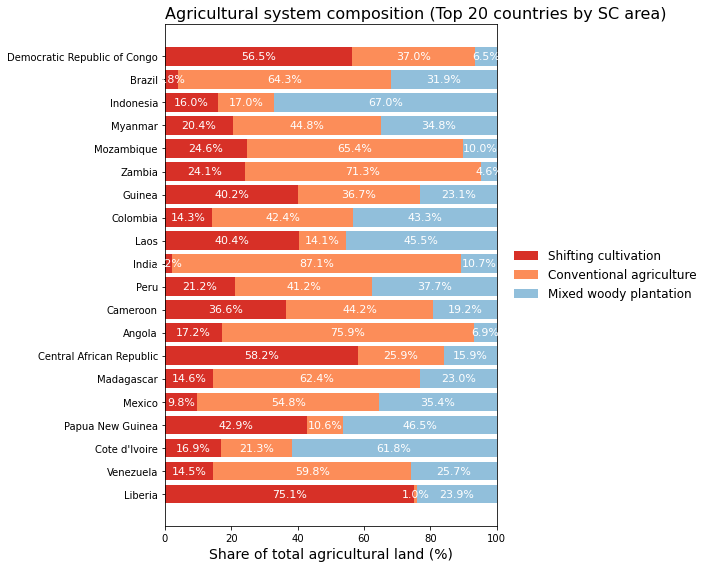

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------
# Prepare data
# -------------------------
# Assume your dataframe 'top20_struct' has:
# "country", "sc_share", "conv_share", "woody_share"



# -------------------------
# Create figure
# -------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# Starting positions for stacking
left_conv = top20_struct["sc_share"].values
left_woody = (top20_struct["sc_share"] + top20_struct["conv_share"]).values

# Stacked horizontal bars
ax.barh(
    top20_struct["country"],
    top20_struct["sc_share"],
    label="Shifting cultivation",
    color="#d73027"  # strong red
)

ax.barh(
    top20_struct["country"],
    top20_struct["conv_share"],
    left=left_conv,
    label="Conventional agriculture",
    color="#fc8d59"  # muted orange
)

ax.barh(
    top20_struct["country"],
    top20_struct["woody_share"],
    left=left_woody,
    label="Mixed woody plantation",
    color="#91bfdb"  # muted blue
)

# -------------------------
# Axes and labels
# -------------------------
ax.set_xlim(0, 100)
ax.set_xlabel("Share of total agricultural land (%)", fontsize=14)
ax.set_ylabel("")
ax.set_title("Agricultural system composition (Top 20 countries by SC area)", fontsize=16, loc="left")

# -------------------------
# Legend
# -------------------------
ax.legend(
    frameon=False,
    fontsize=12,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

# -------------------------
# Optional: Add value labels
# -------------------------
for i, row in enumerate(top20_struct.itertuples()):
    # Shifting cultivation label
    ax.text(row.sc_share / 2, i, f"{row.sc_share:.1f}%", va="center", ha="center", fontsize=11, color="white")
    # Conventional label
    ax.text(left_conv[i] + row.conv_share / 2, i, f"{row.conv_share:.1f}%", va="center", ha="center", fontsize=11, color="white")
    # Woody label
    ax.text(left_woody[i] + row.woody_share / 2, i, f"{row.woody_share:.1f}%", va="center", ha="center", fontsize=11, color="white")


plt.tight_layout()
plt.show()

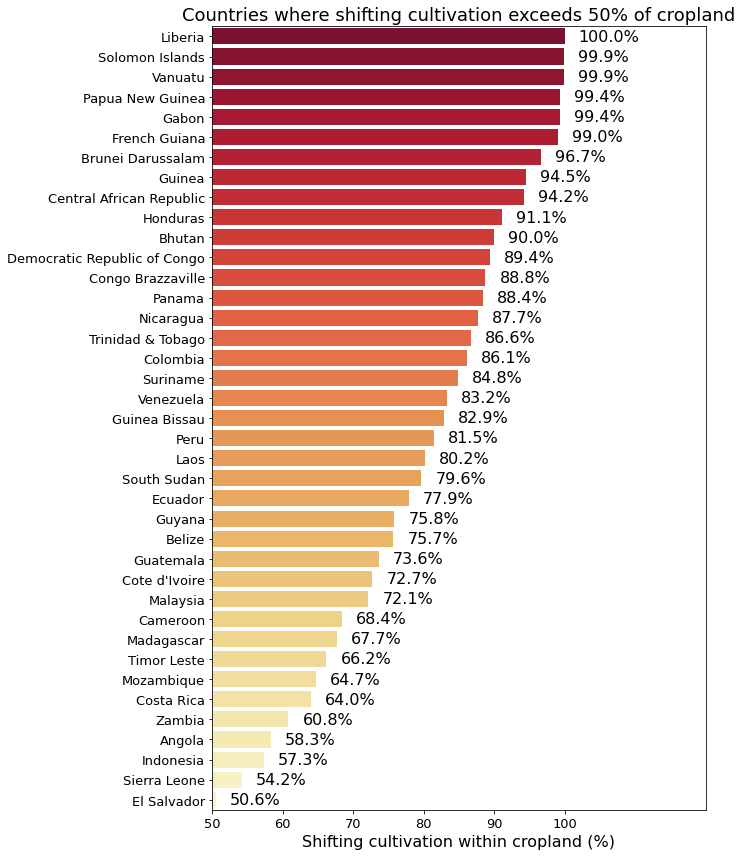

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter countries > 50%
df_plot = countries_records[
    countries_records["sc_percent_of_cropland"] > 50
].sort_values("sc_percent_of_cropland", ascending=False)

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 12))

# Horizontal bar plot
sns.barplot(
    data=df_plot,
    x="sc_percent_of_cropland",
    y="country",
    palette="YlOrRd_r",
    ax=ax
)

# Add value labels
for i, row in enumerate(df_plot.itertuples()):
    ax.text(
        row.sc_percent_of_cropland + df_plot["sc_percent_of_cropland"].max() * 0.02,
        i,
        f"{row.sc_percent_of_cropland:.1f}%",
        va="center",
        fontsize=16
    )

# Axes labels and title
ax.set_xlabel("Shifting cultivation within cropland (%)", fontsize=16)
ax.set_ylabel("")
ax.set_title("Countries where shifting cultivation exceeds 50% of cropland", fontsize=18)

# Adjust x-axis limits and ticks
ax.set_xlim(50, df_plot["sc_percent_of_cropland"].max() * 1.2)
ax.set_xticks([50, 60, 70, 80, 90, 100])

# Tick label sizes
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)

plt.tight_layout()
plt.show()

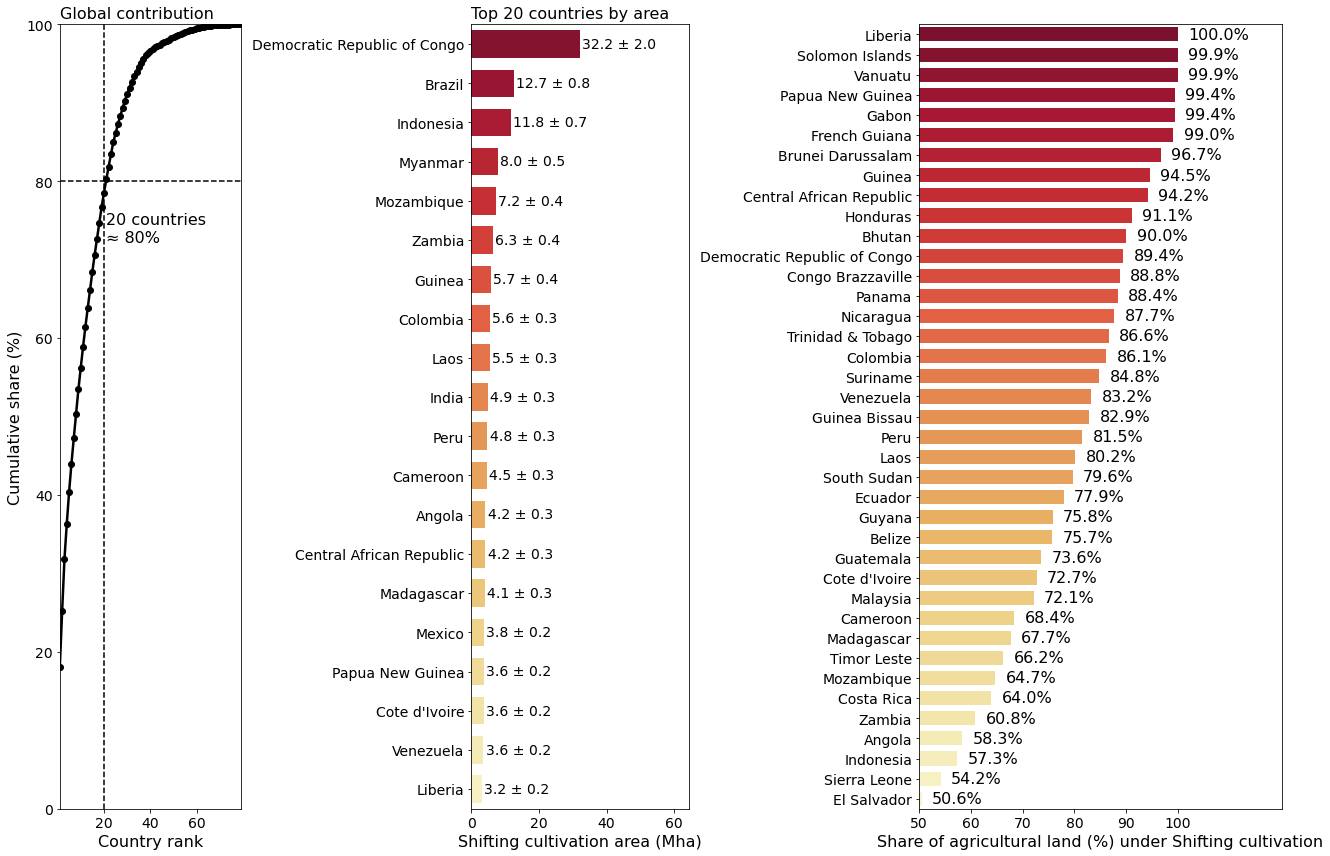

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------
# Global style (Nature-like)
# ------------------
plt.rcParams.update({
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "font.family": "sans-serif"
})

# ------------------
# Prepare data
# ------------------
df = country_counts.sort_values("sc_Mha", ascending=False).copy()

df["cum_area"] = df["sc_Mha"].cumsum()
df["cum_percent"] = 100 * df["cum_area"] / df["sc_Mha"].sum()
df["rank"] = np.arange(1, len(df) + 1)

threshold = 80
n_countries = (df["cum_percent"] <= threshold).sum()

top20 = df.head(20).copy()

# ------------------
# Create 3-panel figure (A4 landscape)
# ------------------
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.2, 2])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ==================
# Panel A: Cumulative curve
# ==================
ax1.plot(
    df["rank"],
    df["cum_percent"],
    marker="o",
    linewidth=2.5,
    color="black"
)

ax1.axhline(threshold, linestyle="--", linewidth=1.5, color="black")
ax1.axvline(n_countries, linestyle="--", linewidth=1.5, color="black")

ax1.set_xlim(1, len(df))
ax1.set_ylim(0, 100)

ax1.set_xlabel("Country rank")
ax1.set_ylabel("Cumulative share (%)")

ax1.text(
    n_countries + 0.8,
    threshold - 4,
    f"{n_countries} countries\n≈ {threshold}%",
    fontsize=16,
    va="top"
)

ax1.set_title("Global contribution", loc="left")

# ==================
# Panel B: Absolute area (Mha ± CI)
# ==================
sns.barplot(
    data=top20,
    x="sc_Mha",
    y="country",
    palette="YlOrRd_r",
    width=0.7,
    ax=ax2
)

ax2.set_xlabel("Shifting cultivation area (Mha)")
ax2.set_ylabel("")
ax2.set_title("Top 20 countries by area", loc="left")

# Annotate ± CI
for i, row in enumerate(top20.itertuples()):
    ax2.text(
        row.sc_Mha + top20["sc_Mha"].max() * 0.02,
        i,
        f"{row.sc_Mha:.1f} ± {row.sc_ci_Mha:.1f}",
        va="center",
        fontsize=14
    )

ax2.set_xlim(0, top20["sc_Mha"].max() * 2)

# ==================
# Panel C: Percentage of country area
# ==================
# Filter countries > 50%
df_plot = countries_records[
    countries_records["sc_percent_of_cropland"] > 50
].sort_values("sc_percent_of_cropland", ascending=False)

sns.barplot(
    data=df_plot,
    x="sc_percent_of_cropland",
    y="country",
    palette="YlOrRd_r",
    width=0.7,
    ax=ax3
)

ax3.set_xlabel("Share of agricultural land (%) under Shifting cultivation")
ax3.set_ylabel("")
ax3.set_title("")

for i, row in enumerate(df_plot.itertuples()):
    ax3.text(
        row.sc_percent_of_cropland + df_plot["sc_percent_of_cropland"].max() * 0.02,
        i,
        f"{row.sc_percent_of_cropland:.1f}%",
        va="center",
        fontsize=16
    )

ax3.set_xlim(50, df_plot["sc_percent_of_cropland"].max() * 1.2)

ax3.set_xticks([50, 60, 70, 80, 90, 100])

# ------------------
# Final layout
# ------------------
plt.tight_layout()

# plt.savefig(
#     "/mnt/warehouse/shifting_cultivation/111_result/figure/revision/"
#     "sc_country_statistics.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()


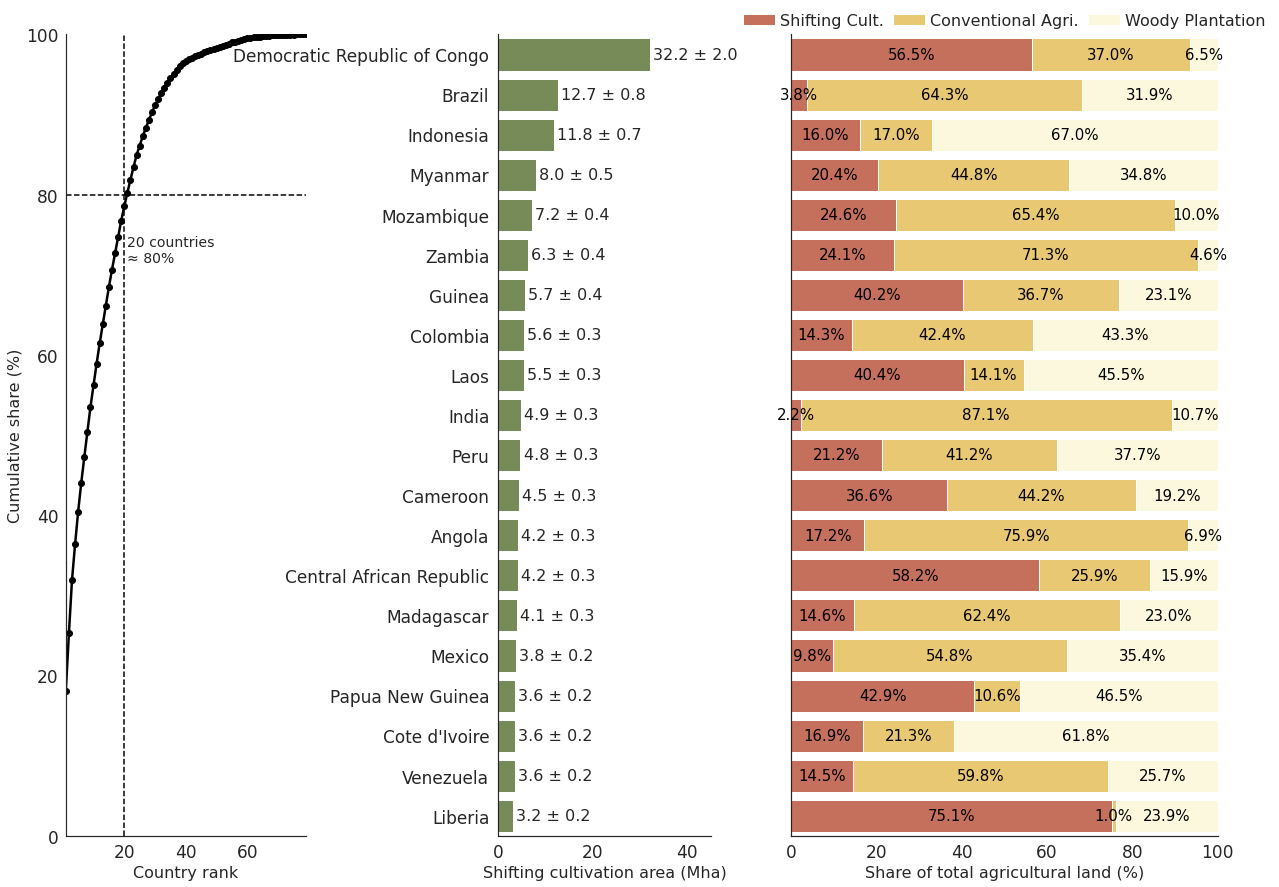

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# ======================
# Global style (Nature-friendly)
# ======================
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.labelsize": 17,
    "axes.titlesize": 17,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "axes.linewidth": 1.2,
})
sns.set_style("white")

# ======================
# Prepare data
# ======================
df = country_counts.sort_values("sc_Mha", ascending=False).copy()
df["cum_area"] = df["sc_Mha"].cumsum()
df["cum_percent"] = 100 * df["cum_area"] / df["sc_Mha"].sum()
df["rank"] = np.arange(1, len(df) + 1)
threshold = 80
n_countries = (df["cum_percent"] <= threshold).sum()
top20 = df.head(20).copy()

# ======================
# Create figure layout
# ======================
fig = plt.figure(figsize=(20, 14))

# Outer GridSpec: Panel A (left) and right block (B & C)
outer_gs = GridSpec(1, 2, width_ratios=[1, 3], wspace=0.4)

# Panel A
ax1 = fig.add_subplot(outer_gs[0])

# Right block: nested 2 panels (B & C)
inner_gs = GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer_gs[1],
    width_ratios=[1.2, 2.4],
    wspace=0.25
)

ax2 = fig.add_subplot(inner_gs[0])
ax3 = fig.add_subplot(inner_gs[1])

# ==========================================================
# Panel A — Cumulative contribution
# ==========================================================
ax1.plot(df["rank"], df["cum_percent"], marker="o", linewidth=2.5, color="black")
ax1.axhline(threshold, linestyle="--", linewidth=1.5, color="black")
ax1.axvline(n_countries, linestyle="--", linewidth=1.5, color="black")

ax1.set_xlim(1, len(df))
ax1.set_ylim(0, 100)
ax1.set_xlabel("Country rank", fontsize=16)
ax1.set_ylabel("Cumulative share (%)", fontsize=16)
ax1.text(n_countries + 1, threshold - 5, f"{n_countries} countries\n≈ {threshold}%", fontsize=14, va="top")
ax1.set_title(" ", fontsize=18)

# ==========================================================
# Panel B — Absolute area
# ==========================================================
sns.barplot(data=top20, x="sc_Mha", y="country", color="#799351", ax=ax2)
ax2.set_xlabel("Shifting cultivation area (Mha)", fontsize=16)
ax2.set_ylabel("")
ax2.set_title(" ", fontsize=18)
ax2.tick_params(axis='y', pad=5)

# Annotate CI
for i, row in enumerate(top20.itertuples()):
    ax2.text(row.sc_Mha + top20["sc_Mha"].max() * 0.02, i,
             f"{row.sc_Mha:.1f} ± {row.sc_ci_Mha:.1f}",
             va="center", fontsize=16)

ax2.set_xlim(0, top20["sc_Mha"].max() * 1.4)

# ==========================================================
# Panel C — Composition
# ==========================================================
left_conv = top20["sc_share"].values
left_woody = (top20["sc_share"] + top20["conv_share"]).values

ax3.barh(top20["country"], top20["sc_share"], label="Shifting Cult.", color="#C5705D")
ax3.barh(top20["country"], top20["conv_share"], left=left_conv, label="Conventional Agri.", color="#E9C874")
ax3.barh(top20["country"], top20["woody_share"], left=left_woody, label="Woody Plantation", color="#FBF8DD")

ax3.set_xlim(0, 100)
ax3.set_xlabel("Share of total agricultural land (%)", fontsize=16)
ax3.set_ylabel("")
ax3.set_title(" ", fontsize=18)

# Remove duplicated country labels
ax3.set_yticks([])
ax3.set_yticklabels([])
ax3.set_ylim(ax2.get_ylim())
ax3.spines["left"].set_visible(False)
ax3.tick_params(axis="y", length=0)

# Add value labels
for i, row in enumerate(top20.itertuples()):
    ax3.text(row.sc_share / 2, i, f"{row.sc_share:.1f}%", va="center", ha="center", fontsize=15, color="black")
    ax3.text(left_conv[i] + row.conv_share / 2, i, f"{row.conv_share:.1f}%", va="center", ha="center", fontsize=15, color="black")
    ax3.text(left_woody[i] + row.woody_share / 2, i, f"{row.woody_share:.1f}%", va="center", ha="center", fontsize=15, color="black")

# ======================
# Horizontal Legend (under title)
# ======================
ax3.legend(
    frameon=False,
    fontsize=16,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.035),  # just under title
    borderaxespad=0.,
    handletextpad=0.3,
    columnspacing=0.6
)

# ======================
# Final clean-up
# ======================
for ax in [ax1, ax2, ax3]:
    sns.despine(ax=ax)

plt.subplots_adjust(left=0.12, right=0.92, top=0.92)

plt.savefig(
    "/mnt/warehouse/shifting_cultivation/111_result/figure/1Fig1_country/"
    "sc_country_statistics_abc.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

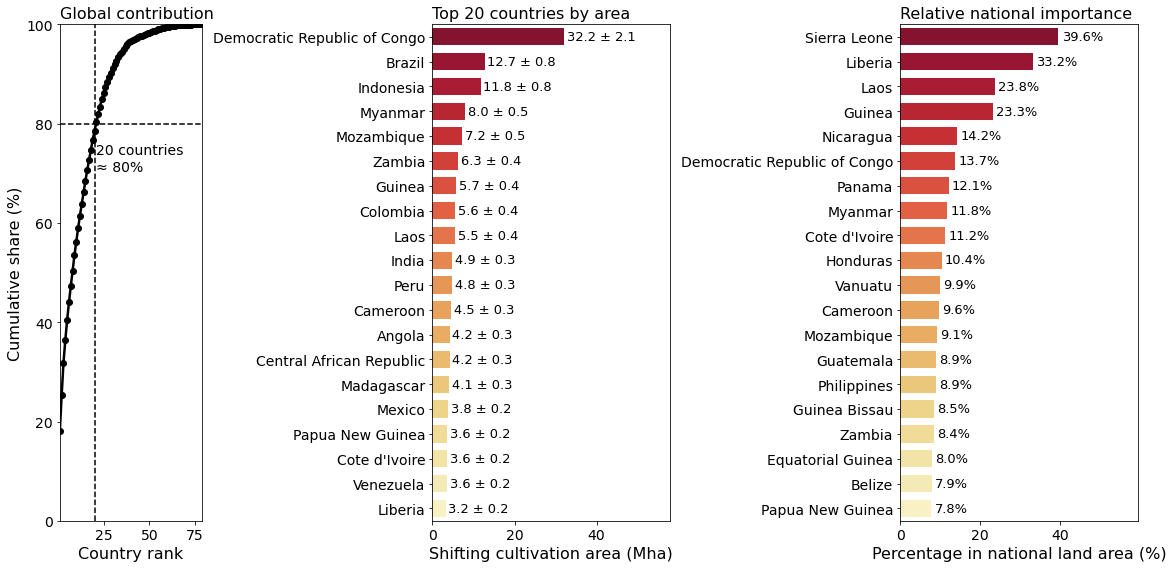

In [69]:
2import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------
# Global style (Nature-like)
# ------------------
plt.rcParams.update({
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "font.family": "sans-serif"
})

# ------------------
# Prepare data
# ------------------
df = country_counts.sort_values("sc_Mha", ascending=False).copy()

df["cum_area"] = df["sc_Mha"].cumsum()
df["cum_percent"] = 100 * df["cum_area"] / df["sc_Mha"].sum()
df["rank"] = np.arange(1, len(df) + 1)

threshold = 80
n_countries = (df["cum_percent"] <= threshold).sum()

top20 = df.head(20).copy()

# ------------------
# Create 3-panel figure (A4 landscape)
# ------------------
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 2.5, 2.5])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ==================
# Panel A: Cumulative curve
# ==================
ax1.plot(
    df["rank"],
    df["cum_percent"],
    marker="o",
    linewidth=2.5,
    color="black"
)

ax1.axhline(threshold, linestyle="--", linewidth=1.5, color="black")
ax1.axvline(n_countries, linestyle="--", linewidth=1.5, color="black")

ax1.set_xlim(1, len(df))
ax1.set_ylim(0, 100)

ax1.set_xlabel("Country rank")
ax1.set_ylabel("Cumulative share (%)")

ax1.text(
    n_countries + 0.8,
    threshold - 4,
    f"{n_countries} countries\n≈ {threshold}%",
    fontsize=14,
    va="top"
)

ax1.set_title("Global contribution", loc="left")

# ==================
# Panel B: Absolute area (Mha ± CI)
# ==================
sns.barplot(
    data=top20,
    x="sc_Mha",
    y="country",
    palette="YlOrRd_r",
    width=0.7,
    ax=ax2
)

ax2.set_xlabel("Shifting cultivation area (Mha)")
ax2.set_ylabel("")
ax2.set_title("Top 20 countries by area", loc="left")

# Annotate ± CI
for i, row in enumerate(top20.itertuples()):
    ax2.text(
        row.sc_Mha + top20["sc_Mha"].max() * 0.02,
        i,
        f"{row.sc_Mha:.1f} ± {row.sc_ci_Mha:.1f}",
        va="center",
        fontsize=13
    )

ax2.set_xlim(0, top20["sc_Mha"].max() * 1.8)

# ==================
# Panel C: Percentage of country area
# ==================
top20_pct = country_counts.sort_values("sc_percent_of_country", ascending=False)[:20]

sns.barplot(
    data=top20_pct,
    x="sc_percent_of_country",
    y="country",
    palette="YlOrRd_r",
    width=0.7,
    ax=ax3
)

ax3.set_xlabel("Percentage in national land area (%)")
ax3.set_ylabel("")
ax3.set_title("Relative national importance", loc="left")

for i, row in enumerate(top20_pct.itertuples()):
    ax3.text(
        row.sc_percent_of_country + top20_pct["sc_percent_of_country"].max() * 0.02,
        i,
        f"{row.sc_percent_of_country:.1f}%",
        va="center",
        fontsize=13
    )

ax3.set_xlim(0, top20_pct["sc_percent_of_country"].max() * 1.5)

# ------------------
# Final layout
# ------------------
plt.tight_layout()

# plt.savefig(
#     "/mnt/warehouse/shifting_cultivation/111_result/figure/"
#     "sc_country_three_panel_A4_Nature.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()


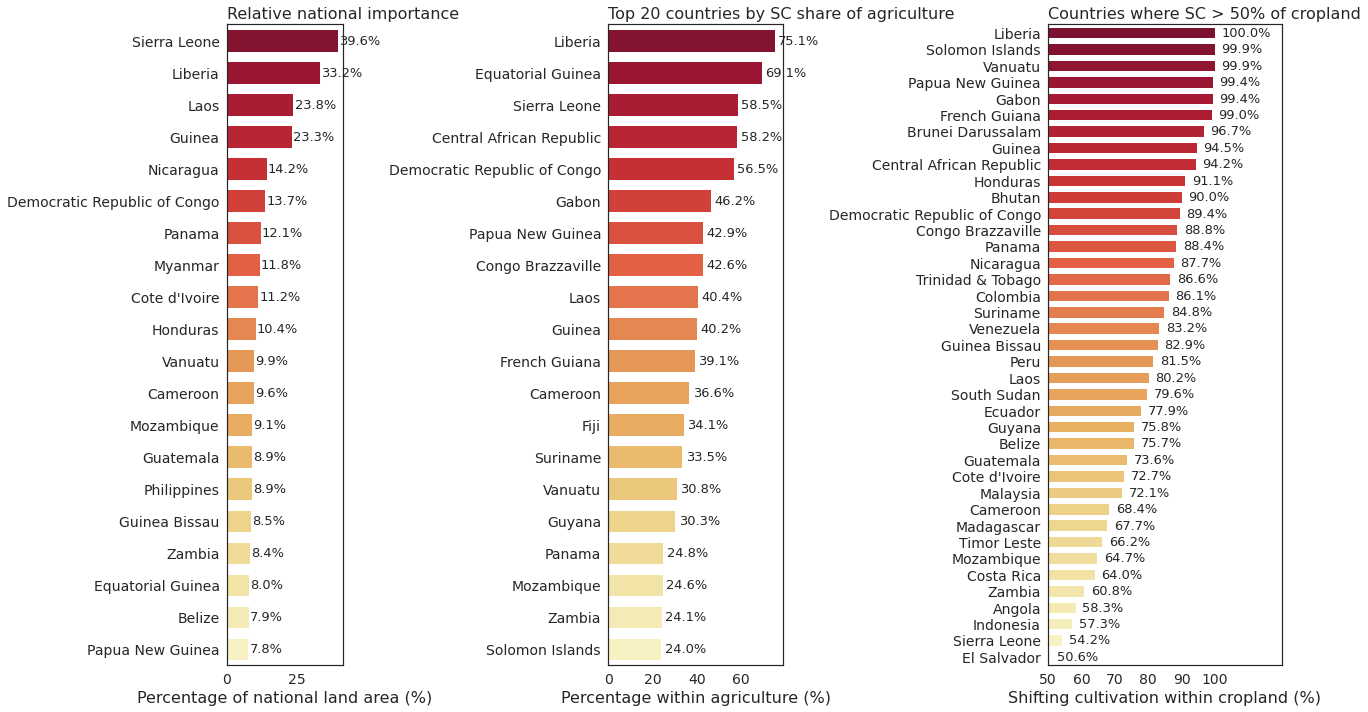

In [218]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make copies to avoid SettingWithCopy issues
top20_pct_plot = top20_pct.copy()
countries_records_plot = countries_records.sort_values("sc_percent_of_agriculture", ascending=False).copy()
df_plot_copy = df_plot.copy()

# Replace long country name with "DRC"
for df in [top20_pct_plot, countries_records_plot, df_plot_copy]:
    df["country"] = df["country"].replace("Democratic Republic of the Congo", "DRC")
    df["country"] = df["country"].astype(str)

# ------------------
# Create 3-panel figure (A4 landscape)
# ------------------
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.5, 2])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# -----------------------------
# Panel 1: SC % in national land
# -----------------------------
sns.barplot(
    data=top20_pct_plot,
    x="sc_percent_of_country",
    y="country",
    palette="YlOrRd_r",
    width=0.7,
    ax=ax1  # corrected
)

ax1.set_xlabel("Percentage of national land area (%)", fontsize=16)
ax1.set_ylabel("")
ax1.set_title("Relative national importance", fontsize=16, loc="left")
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

for i, row in enumerate(top20_pct_plot.itertuples()):
    ax1.text(
        row.sc_percent_of_country + top20_pct_plot["sc_percent_of_country"].max() * 0.01,
        i,
        f"{row.sc_percent_of_country:.1f}%",
        va="center",
        fontsize=13
    )

# -----------------------------
# Panel 2: SC % in total agriculture
# -----------------------------
sns.barplot(
    data=countries_records_plot[:20],
    x="sc_percent_of_agriculture",
    y="country",
    palette="YlOrRd_r",
    width=0.7,
    ax=ax2  # corrected
)

ax2.set_xlabel("Percentage within agriculture (%)", fontsize=16)
ax2.set_ylabel("")
ax2.set_title("Top 20 countries by SC share of agriculture", fontsize=16, loc="left")
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

for i, row in enumerate(countries_records_plot[:20].itertuples()):
    ax2.text(
        row.sc_percent_of_agriculture + countries_records_plot["sc_percent_of_agriculture"].max() * 0.02,
        i,
        f"{row.sc_percent_of_agriculture:.1f}%",
        va="center",
        fontsize=13
    )

# -----------------------------
# Panel 3: SC > 50% cropland
# -----------------------------
sns.barplot(
    data=df_plot_copy,
    x="sc_percent_of_cropland",
    y="country",
    palette="YlOrRd_r",
    width=0.7,
    ax=ax3  # corrected
)

ax3.set_xlabel("Shifting cultivation within cropland (%)", fontsize=16)
ax3.set_ylabel("")
ax3.set_title("Countries where SC > 50% of cropland", fontsize=16, loc="left")
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)

for i, row in enumerate(df_plot_copy.itertuples()):
    ax3.text(
        row.sc_percent_of_cropland + df_plot_copy["sc_percent_of_cropland"].max() * 0.02,
        i,
        f"{row.sc_percent_of_cropland:.1f}%",
        va="center",
        fontsize=13
    )

ax3.set_xlim(50, df_plot_copy["sc_percent_of_cropland"].max() * 1.2)
ax3.set_xticks([50, 60, 70, 80, 90, 100])

# -----------------------------
# Adjust layout
# -----------------------------
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()

plt.savefig(
    "/mnt/warehouse/shifting_cultivation/111_result/figure/"
    "sc_country_three_panel_extended_data.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [17]:
country_counts["sc_percent_of_country"] = (
    country_counts["class_1_km2"] / country_counts["country_area_km2"] * 100)

In [18]:
# Compute total agriculture
country_counts["total_agri_km2"] = (
    country_counts["class_1_km2"] +
    country_counts["class_3_km2"] +
    country_counts["class_4_km2"]
)

# Convert to percentage shares
country_counts["sc_share"] = country_counts["class_1_km2"] / country_counts["total_agri_km2"] * 100
country_counts["conv_share"] = country_counts["class_3_km2"] / country_counts["total_agri_km2"] * 100
country_counts["woody_share"] = country_counts["class_4_km2"] / country_counts["total_agri_km2"] * 100

In [19]:
top20_struct = country_counts.sort_values("sc_Mha", ascending=False).head(20).iloc[::-1]   # reverse order for plotting

/tmp/ipykernel_374571/3870016301.py:220: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


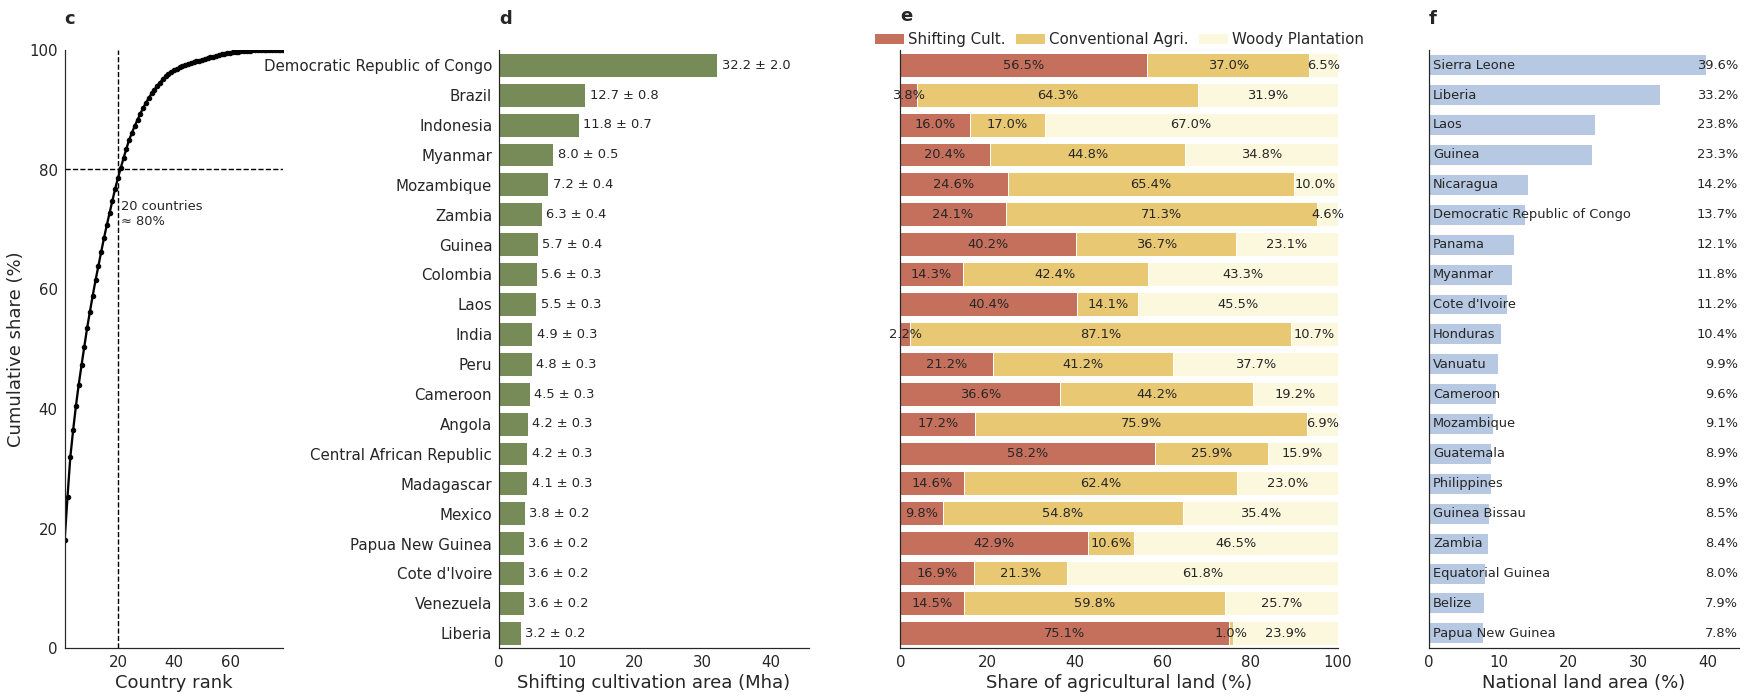

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec

# ======================
# Global style (Nature Sustainability optimized)
# ======================
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.linewidth": 1.2,
})

sns.set_style("white")

# ======================
# Prepare data
# ======================
df = country_counts.sort_values("sc_Mha", ascending=False).copy()
df_copy = country_counts.sort_values("sc_percent_of_country", ascending=False).copy()

for d in [df, df_copy]:
    d["country"] = d["country"].replace({
        "Democratic Republic of the Congo": "DRC"
    }).astype(str)

df["cum_area"] = df["sc_Mha"].cumsum()
df["cum_percent"] = 100 * df["cum_area"] / df["sc_Mha"].sum()
df["rank"] = np.arange(1, len(df) + 1)

threshold = 80
n_countries = (df["cum_percent"] <= threshold).sum()

top20 = df.head(20).copy()

top20_pct_plot = (
    df_copy.sort_values("sc_percent_of_country", ascending=False)
    .head(20)
    .copy()
)

maxv = top20_pct_plot["sc_percent_of_country"].max()

# ======================
# Figure 1 × 4 layout
# ======================
fig = plt.figure(figsize=(30, 11))

gs = GridSpec(
    1, 5,
    width_ratios=[1.2, 0.18, 1.7, 2.4, 1.7],
    wspace=0.35
)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])
ax4 = fig.add_subplot(gs[4])

# ----------------------
# Panel a: cumulative concentration
# ----------------------
ax1.plot(
    df["rank"],
    df["cum_percent"],
    marker="o",
    linewidth=2.3,
    markersize=4.5,
    color="black"
)

ax1.axhline(threshold, linestyle="--", linewidth=1.4, color="black")
ax1.axvline(n_countries, linestyle="--", linewidth=1.4, color="black")

ax1.text(
    n_countries + 1,
    threshold - 5,
    f"{n_countries} countries\n≈ {threshold}%",
    fontsize=13,
    va="top"
)

ax1.set_xlim(1, len(df))
ax1.set_ylim(0, 100)
ax1.set_xlabel("Country rank")
ax1.set_ylabel("Cumulative share (%)")
ax1.set_title("c", loc="left", fontweight="bold", pad=26)

# ----------------------
# Panel b: absolute area
# ----------------------
sns.barplot(
    data=top20,
    x="sc_Mha",
    y="country",
    color="#799351",
    ax=ax2
)

ax2.set_xlabel("Shifting cultivation area (Mha)")
ax2.set_ylabel("")
ax2.set_title("d", loc="left", fontweight="bold", pad=26)

for i, row in enumerate(top20.itertuples()):
    ax2.text(
        row.sc_Mha + top20["sc_Mha"].max() * 0.02,
        i,
        f"{row.sc_Mha:.1f} ± {row.sc_ci_Mha:.1f}",
        va="center",
        fontsize=13
    )

ax2.set_xlim(0, top20["sc_Mha"].max() * 1.42)

# ----------------------
# Panel c: composition
# ----------------------
left_conv = top20["sc_share"].values
left_woody = (top20["sc_share"] + top20["conv_share"]).values

ax3.barh(top20["country"], top20["sc_share"],
         label="Shifting Cult.", color="#C5705D")

ax3.barh(top20["country"], top20["conv_share"],
         left=left_conv,
         label="Conventional Agri.",
         color="#E9C874")

ax3.barh(top20["country"], top20["woody_share"],
         left=left_woody,
         label="Woody Plantation",
         color="#FBF8DD")

ax3.set_xlim(0, 100)
ax3.set_xlabel("Share of agricultural land (%)")
ax3.set_ylabel("")
ax3.set_title("e", loc="left", fontweight="bold", pad=29)

ax3.set_yticks([])
ax3.set_yticklabels([])
ax3.set_ylim(ax2.get_ylim())
ax3.spines["left"].set_visible(False)
ax3.tick_params(axis="y", length=0)

for i, row in enumerate(top20.itertuples()):
    ax3.text(row.sc_share/2, i, f"{row.sc_share:.1f}%",
             ha="center", va="center", fontsize=13)
    ax3.text(left_conv[i] + row.conv_share/2, i, f"{row.conv_share:.1f}%",
             ha="center", va="center", fontsize=13)
    ax3.text(left_woody[i] + row.woody_share/2, i, f"{row.woody_share:.1f}%",
             ha="center", va="center", fontsize=13)

ax3.legend(
    frameon=False,
    fontsize=15,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    borderaxespad=0.,
    handletextpad=0.3,
    columnspacing=0.6
)

# ----------------------
# Panel d: relative national importance
# ----------------------
sns.barplot(
    data=top20_pct_plot,
    x="sc_percent_of_country",
    y="country",
    color="#AFC6E9",
    width=0.7,
    ax=ax4
)

ax4.set_xlabel("National land area (%)")
ax4.set_ylabel("")
ax4.set_title("f", loc="left", fontweight="bold", pad=26)

# remove outer labels
ax4.set_yticklabels([])
ax4.tick_params(axis='y', length=0)

ax4.set_xlim(0, maxv * 1.12)

x_right = ax4.get_xlim()[1]

for i, row in enumerate(top20_pct_plot.itertuples()):

    # country labels inside bars
    ax4.text(
        0.55,
        i,
        row.country,
        va="center",
        ha="left",
        fontsize=13
    )

    # aligned percentages
    ax4.text(
        x_right - 0.08,
        i,
        f"{row.sc_percent_of_country:.1f}%",
        va="center",
        ha="right",
        fontsize=13
    )

# ----------------------
# Clean
# ----------------------
for ax in [ax1, ax2, ax3, ax4]:
    sns.despine(ax=ax)

plt.tight_layout()

# plt.savefig(
#     "/mnt/warehouse/shifting_cultivation/111_result/figure/1Fig1_country/"
#     "Fig1_country_statistics_4panel_new.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()

In [28]:
country_counts["sc_percent_of_cropland"] = country_counts["class_1_km2"] *0.1 * 100/ (country_counts["class_1_km2"] *0.1 + country_counts["cropland_area"])
country_counts["sc_percent_of_agriculture"] = country_counts["class_1_km2"] * 100/ (country_counts["class_1_km2"] + country_counts["class_3_km2"] + country_counts["class_4_km2"])

In [29]:
# Sort by percentage
countries_records = country_counts.sort_values(by="sc_percent_of_agriculture", ascending=False)

In [30]:
# Filter countries > 50%
df_plot = countries_records[
    countries_records["sc_percent_of_cropland"] > 50
].sort_values("sc_percent_of_cropland", ascending=False)

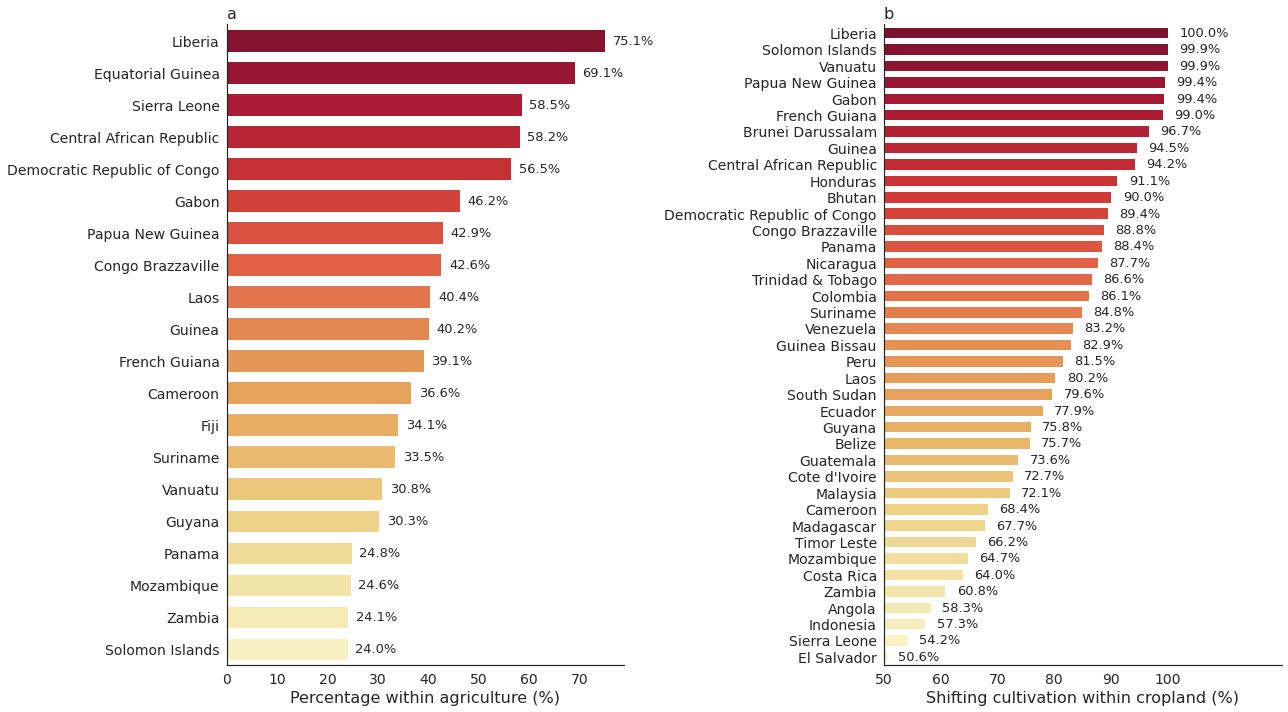

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make copies to avoid SettingWithCopy issues
#top20_pct_plot = top20_pct.copy()
countries_records_plot = countries_records.sort_values("sc_percent_of_agriculture", ascending=False).copy()
df_plot_copy = df_plot.copy()

# Replace long country name with "DRC"
for df in [top20_pct_plot, countries_records_plot, df_plot_copy]:
    df["country"] = df["country"].replace("Democratic Republic of the Congo", "DRC")
    df["country"] = df["country"].astype(str)

# ------------------
# Create 3-panel figure (A4 landscape)
# ------------------
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1.5])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


# -----------------------------
# Panel 2: SC % in total agriculture
# -----------------------------
sns.barplot(
    data=countries_records_plot[:20],
    x="sc_percent_of_agriculture",
    y="country",
    palette="YlOrRd_r",
    width=0.7,
    ax=ax1  # corrected
)

ax1.set_xlabel("Percentage within agriculture (%)", fontsize=16)
ax1.set_ylabel("")
ax1.set_title("a", fontsize=16, loc="left")
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

for i, row in enumerate(countries_records_plot[:20].itertuples()):
    ax1.text(
        row.sc_percent_of_agriculture + countries_records_plot["sc_percent_of_agriculture"].max() * 0.02,
        i,
        f"{row.sc_percent_of_agriculture:.1f}%",
        va="center",
        fontsize=13
    )

# -----------------------------
# Panel 3: SC > 50% cropland
# -----------------------------
sns.barplot(
    data=df_plot_copy,
    x="sc_percent_of_cropland",
    y="country",
    palette="YlOrRd_r",
    width=0.7,
    ax=ax2  # corrected
)

ax2.set_xlabel("Shifting cultivation within cropland (%)", fontsize=16)
ax2.set_ylabel("")
ax2.set_title("b", fontsize=16, loc="left")
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

for i, row in enumerate(df_plot_copy.itertuples()):
    ax2.text(
        row.sc_percent_of_cropland + df_plot_copy["sc_percent_of_cropland"].max() * 0.02,
        i,
        f"{row.sc_percent_of_cropland:.1f}%",
        va="center",
        fontsize=13
    )

ax2.set_xlim(50, df_plot_copy["sc_percent_of_cropland"].max() * 1.2)
ax2.set_xticks([50, 60, 70, 80, 90, 100])

ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)

ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)

# -----------------------------
# Adjust layout
# -----------------------------
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()

plt.savefig(
    "/mnt/warehouse/shifting_cultivation/111_result/figure/"
    "sc_country_two_panel_extended_data.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()